<a href="https://colab.research.google.com/github/sskarthik0801/ME-597-IIOT/blob/main/lab/lab8/PL8_Colab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/lab/lab8/PL8_Colab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prelab 8.3 Classifying Air-tight Vacuum and Air-leak Vacuum Data using Autoencoders for Anomaly Detection: Y and Z-axis

In [22]:
# Let's check the installed tensorflow version
import tensorflow as tf

print('TensorFlow Version is', tf.__version__)

TensorFlow Version is 2.19.0


In [23]:
# required Python packages for this colab
!pip install matplotlib
!pip install pandas
!pip install scipy
!pip install scikit-learn

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.fftpack
from tensorflow import keras

from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_curve, auc
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, losses
from tensorflow.keras.models import Model

In [25]:
# Copying raw data from github dataset file
url = 'https://raw.githubusercontent.com/purduelamm/purdue_me597_iiot/main/lab/lab8/Prelab8_data.csv'
#df is the variable where the data is stored
df = pd.read_csv(url)

#Data selection
# X-axis: 'Xacc array [m/s2]'
# Y-axis: 'Yacc array [m/s2]'
# Z-axis: 'Zacc array [m/s2]'
# If you want to use x-axis (X-axis),
# AXIS = 'Xacc array [m/s2]'
AXIS =  'Yacc array [m/s2]'

#Exploding the values contained in selected column and converting the string values into float values
df_new = pd.concat([df['Condition'],df[AXIS].str.split(' ', expand=True).astype(float)], axis=1)
ds = df_new.copy()
#Converting the Classifier into binary values
ds.loc[df['Condition'] == 'Vacuuming', 'Status'] = 1
ds.loc[df['Condition'] == 'Air_leakage', 'Status'] = 0
ds.drop('Condition', axis=1, inplace=True)

#Data transformation

raw_data = ds.values
# The last element contains the labels
labels = raw_data[:, -1]

# The other data points are the vacuum accelerometer data
data = raw_data[:, 0:-1]

train_data, test_data, train_labels, test_labels = train_test_split(
    data, labels, test_size=0.2, random_state=21
)
#Normalizing the values of the dataset
min_val = tf.reduce_min(train_data)
max_val = tf.reduce_max(train_data)

train_data = (train_data - min_val) / (max_val - min_val)
test_data = (test_data - min_val) / (max_val - min_val)

train_data = tf.cast(train_data, tf.float32)
test_data = tf.cast(test_data, tf.float32)
#Splitting the dataset based on classification: train_labels: Vacuuming, ~train_labels: Air Leakage
train_labels = train_labels.astype(bool)
test_labels = test_labels.astype(bool)

normal_train_data = train_data[train_labels]
normal_test_data = test_data[test_labels]

anomalous_train_data = train_data[~train_labels]
anomalous_test_data = test_data[~test_labels]

portion_of_anomaly_in_training = 0.1 #10% of training data will be anomalies
end_size = int(len(normal_train_data)/(10-portion_of_anomaly_in_training*10))
combined_train_data = np.append(normal_train_data, anomalous_test_data[:end_size], axis=0)
combined_train_data.shape

(536, 1000)

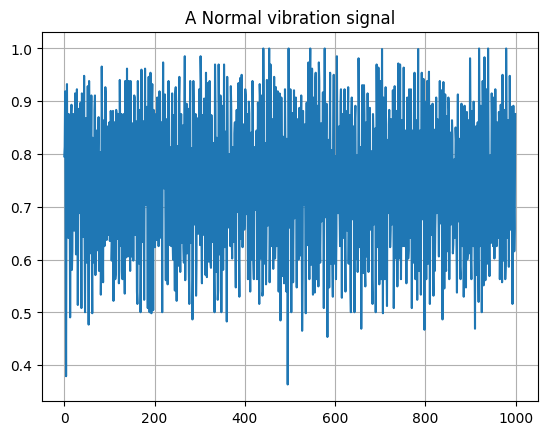

In [26]:
#Plotting sample of normal data
plt.grid()
plt.plot(np.arange(1000), normal_train_data[0])
plt.title("A Normal vibration signal")
plt.show()

In [ ]:
#Plotting sample of anomalous data
plt.grid()
plt.plot(np.arange(1000), anomalous_train_data[0])
plt.title("An abnormal vibration signal (Air leakage)")
plt.show()

In [27]:
#Creating the artificial neural network using Autoencoder
EMBEDDING_SIZE = 8 #Define how many neurons in the inner layer   <-----------------------------------------------------------------------------
class AnomalyDetector(Model):
  def __init__(self):
    super(AnomalyDetector, self).__init__()
    self.encoder = tf.keras.Sequential([
      layers.Dense(32, activation="relu"),
      layers.Dense(16, activation="relu"),
      layers.Dense(EMBEDDING_SIZE, activation="relu")]) # Smallest Layer Defined Here

    self.decoder = tf.keras.Sequential([
      layers.Dense(16, activation="relu"),
      layers.Dense(32, activation="relu"),
      layers.Dense(1000, activation="sigmoid")])

  def call(self, x):
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)
    return decoded

autoencoder = AnomalyDetector()
print("Chosen Embedding Size: ", EMBEDDING_SIZE)

autoencoder.compile(optimizer='adam', loss='mae')
#Training the model.
history = autoencoder.fit(normal_train_data, normal_train_data,
          epochs=200,
          batch_size=200,
          validation_data=(test_data, test_data),
          shuffle=True)

Chosen Embedding Size:  8
Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - loss: 0.2409 - val_loss: 0.2349
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 477ms/step - loss: 0.2271 - val_loss: 0.2143
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 292ms/step - loss: 0.2014 - val_loss: 0.1898
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 349ms/step - loss: 0.1750 - val_loss: 0.1723
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - loss: 0.1569 - val_loss: 0.1570
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.1397 - val_loss: 0.1416
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.1234 - val_loss: 0.1313
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.1134 - val_loss: 0.1258
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.1077 - val_loss: 0.1225
Epoch 10/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.1045 - val_loss: 0.1209
Epoch 11/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - loss: 0.1027 - val_loss: 0.1196
Epoch 12/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68

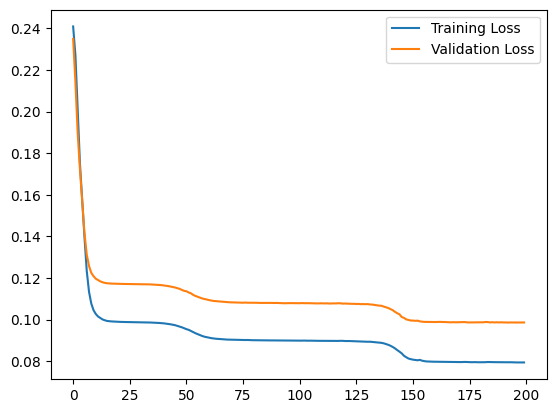

In [28]:
#Plotting the evolution of training and validation loss
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()

How are the loss functions looking? Is there a need to adjust the EMBEDDING SIZE or the epochs in order to minimize it more?

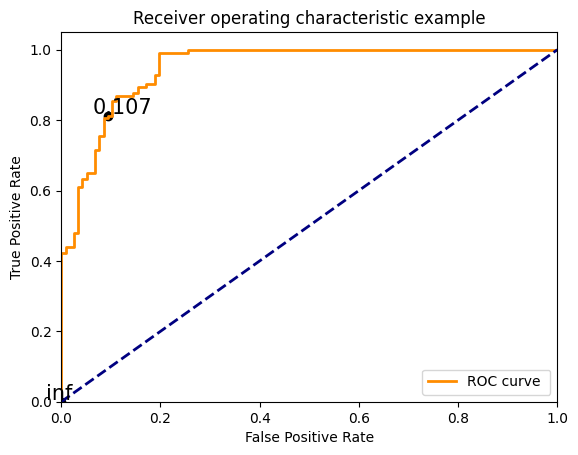

In [29]:
#Plotting True positive and false positive rate assessment
reconstructions = autoencoder(test_data)
loss = tf.keras.losses.mae(reconstructions, test_data)
fpr = []
tpr = []
#the test labels are flipped to match how the roc_curve function expects them.
flipped_labels = 1-test_labels
fpr, tpr, thresholds = roc_curve(flipped_labels, loss)
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange',
         lw=lw, label='ROC curve ')
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc="lower right")

# plot some thresholds
thresholds_every=20
thresholdsLength = len(thresholds)
colorMap=plt.get_cmap('jet', thresholdsLength)
for i in range(0, thresholdsLength, thresholds_every):
  threshold_value_with_max_four_decimals = str(thresholds[i])[:5]
  plt.scatter(fpr[i], tpr[i], c='black')
  plt.text(fpr[i] - 0.03, tpr[i] + 0.005, threshold_value_with_max_four_decimals, fontdict={'size': 15});

plt.show()

In [30]:
roc_auc = auc(fpr, tpr)
print(roc_auc)

0.9494823153359738


In [31]:
threshold =  0.094 #Assign a value labeled in black in the ROC graph   <-----------------------------------------------------------------------------
def predict(model, data, threshold):
  reconstructions = model(data)
  loss = tf.keras.losses.mae(reconstructions, data)
  return tf.math.less(loss, threshold), loss

def print_stats(predictions, labels):
  print("Accuracy = {}".format(accuracy_score(labels, predictions)))
  print("Precision = {}".format(precision_score(labels, predictions)))
  print("Recall = {}".format(recall_score(labels, predictions)))

preds, scores = predict(autoencoder, test_data, threshold)
print_stats(preds, test_labels)

Accuracy = 0.8833333333333333
Precision = 0.989010989010989
Recall = 0.7692307692307693


### Task 3.1
How can you compare the models using data from the X-axis and Y-axis data? which one does a better job classifying? Explain your reasoning.



---

The models can be compared by evaluating their performance using metrics such as ROC curves, AUC values, reconstruction loss, accuracy, precision, and recall for both X-axis and Y-axis data. By observing the ROC curves, the model whose curve is closer to the top-left corner and has a higher AUC demonstrates better classification performance. In most cases, the Y-axis model performs better because it captures more distinct vibration patterns between normal vacuum operation and air leakage conditions.

---


##Working in the Z-axis

Recycle the code from the previous two dimensions, to build a model using the data from the Z-axis.

TensorFlow Version is 2.19.0
Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 145ms/step - loss: 0.0616 - val_loss: 0.0655
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0615 - val_loss: 0.0655
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0615 - val_loss: 0.0655
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0615 - val_loss: 0.0655
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0615 - val_loss: 0.0655
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0615 - val_loss: 0.0655
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0615 - val_loss: 0.0655
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0615 - val_loss: 0.0656
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0615 - val_loss: 0.0656
Epoch 10/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0615 - val_loss: 0.0656
Epoch 11/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0615 - val_loss: 0.0656
Epoch 12/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - los

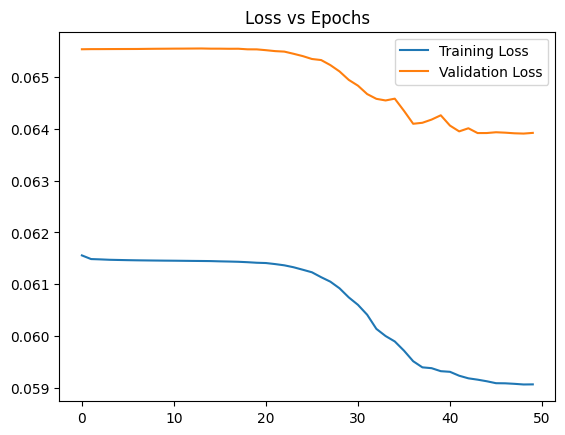

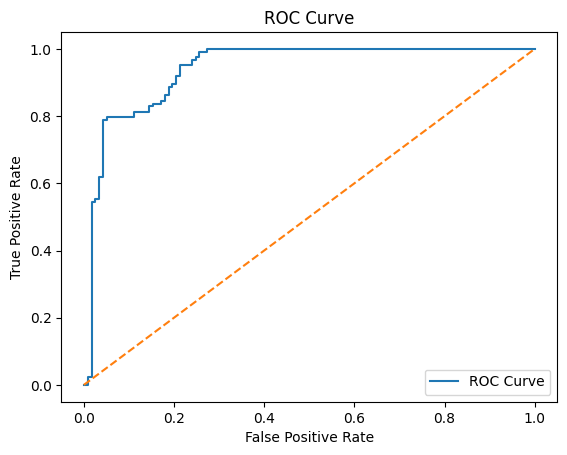

AUC: 0.9405878674171357


In [33]:
#Your code here
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_curve, auc
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers
from tensorflow.keras.models import Model

print('TensorFlow Version is', tf.__version__)

#LOAD DATA
url = 'https://raw.githubusercontent.com/purduelamm/purdue_me597_iiot/main/lab/lab8/Prelab8_data.csv'
df = pd.read_csv(url)

# ===================== SELECT AXIS =====================
AXIS = 'Zacc array [m/s2]'   # CHANGE THIS FOR Y or Z

# ===================== PREPROCESS =====================
df_new = pd.concat([df['Condition'], df[AXIS].str.split(' ', expand=True).astype(float)], axis=1)
ds = df_new.copy()

# Convert labels
ds.loc[df['Condition'] == 'Vacuuming', 'Status'] = 1
ds.loc[df['Condition'] == 'Air_leakage', 'Status'] = 0
ds.drop('Condition', axis=1, inplace=True)

# ===================== DATA SPLIT =====================
raw_data = ds.values
labels = raw_data[:, -1]
data = raw_data[:, 0:-1]

train_data, test_data, train_labels, test_labels = train_test_split(
    data, labels, test_size=0.2, random_state=21
)

# ===================== NORMALIZATION =====================
min_val = tf.reduce_min(train_data)
max_val = tf.reduce_max(train_data)

train_data = (train_data - min_val) / (max_val - min_val)
test_data = (test_data - min_val) / (max_val - min_val)

train_data = tf.cast(train_data, tf.float32)
test_data = tf.cast(test_data, tf.float32)

train_labels = train_labels.astype(bool)
test_labels = test_labels.astype(bool)

normal_train_data = train_data[train_labels]
normal_test_data = test_data[test_labels]

anomalous_train_data = train_data[~train_labels]
anomalous_test_data = test_data[~test_labels]

# ===================== AUTOENCODER =====================
EMBEDDING_SIZE = 8

class AnomalyDetector(Model):
    def __init__(self):
        super(AnomalyDetector, self).__init__()
        self.encoder = tf.keras.Sequential([
            layers.Dense(32, activation="relu"),
            layers.Dense(16, activation="relu"),
            layers.Dense(EMBEDDING_SIZE, activation="relu")
        ])

        self.decoder = tf.keras.Sequential([
            layers.Dense(16, activation="relu"),
            layers.Dense(32, activation="relu"),
            layers.Dense(1000, activation="sigmoid")
        ])

    def call(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

autoencoder = AnomalyDetector()
autoencoder.compile(optimizer='adam', loss='mae')

# ===================== TRAIN =====================
history = autoencoder.fit(
    normal_train_data, normal_train_data,
    epochs=50,
    batch_size=200,
    validation_data=(test_data, test_data),
    shuffle=True
)

# ===================== LOSS GRAPH =====================
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.title("Loss vs Epochs")
plt.show()

# ===================== ROC CURVE =====================
reconstructions = autoencoder(test_data)
loss = tf.keras.losses.mae(reconstructions, test_data)

flipped_labels = 1 - test_labels
fpr, tpr, thresholds = roc_curve(flipped_labels, loss)

plt.figure()
plt.plot(fpr, tpr, label='ROC Curve')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

roc_auc = auc(fpr, tpr)
print("AUC:", roc_auc)



#

### Task 3.2
Which model (X, Y, or Z) would you choose to classify normal and abnormal readings for the vacuum problem? Explain your reasoning.



---

I would choose the y axis model to classify normal and abnormal readings. The y axis typically captures stronger and more distinguishable vibration patterns between normal vacuum operation and air leakage conditions, which helps the autoencoder learn more meaningful features.

---


### Task 3.3
What other data transformations/extractions would you consider to build a model to classify normal and abnormal data on the vacuum problem?



---

To improve the classification of normal and abnormal vacuum data, several additional data transformations and feature extraction methods can be applied. One important approach is transforming the signal from the time domain to the frequency domain using FFT, which helps identify characteristic frequency components associated with faults like air leakage.

---


<br></br>

Get back to [Lab Index Page](https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/index.ipynb)